# <span style='color:Red'>Misbinding models (Part 1)</span>

## <span style='color:Red'>Libraries, functions, paths</span>

In [1]:
import sys, os
from pathlib import Path

currentWD = os.path.dirname(Path.cwd())
if currentWD not in sys.path:
    sys.path.append(currentWD)
#print(sys.path)

import numpy, pandas, re, ast, seaborn, jlib, sklearn, pickle
from matplotlib import pyplot
from scipy.stats import vonmises

saveFigs = True
imagePath = 'img/models/'
imageFormat = 'svg'
exportsPathBase = 'exports/'
exportsPath = 'exports/biasModels/'
exportsPathTemp = 'exports/biasModels/temp/partial/'

desiredEffectSize = 'ges'

metricToCalculate = 'NormLL'

numpy.random.seed(1)

if not os.path.exists(imagePath):
    os.makedirs(imagePath)

if not os.path.exists(exportsPath):
    os.makedirs(exportsPath)

if not os.path.exists(exportsPathTemp):
    os.makedirs(exportsPathTemp)

mapValueHandler = jlib.data.mapValueHandler.MapValueHandler(exportsPathBase+"exp3Values.csv")

allParticipantData = pandas.read_csv(exportsPathBase+'participantData_long_preEEG.csv')
allParticipantData.drop(['Mouse X path','Mouse Y path','Target'],axis=1,inplace=True)

## <span style='color:Red'>Fit functions for all participants</span>

In [ ]:
allBaseFits = {'MBSK':[],'MBDK':[],'NMB':[],'Bias':[]}
allBaseLL = {'MBSK':[],'MBDK':[],'NMB':[],'Bias':[]}

for participant in numpy.unique(allParticipantData['Subject']):
    participantData = allParticipantData[allParticipantData['Subject']==participant]

    allErrors = participantData['Response error'].to_numpy()*numpy.pi/180
    allTargets = numpy.zeros(allErrors.shape)
    allMeanErrors = participantData['Continuous target'].to_numpy()-participantData['Mean target'].to_numpy()
    allMeanErrors = allMeanErrors*2*numpy.pi/jlib.compression.constants.EXP3_RESPONSE_SECTIONS

    # Misbinding with single, shared kappa
    params,logLikelihood,_ = jlib.analysis.models.fitMisbindingMultiVonMises(allErrors,allTargets,allMeanErrors[:,None])
    allBaseFits['MBSK'].append(params)
    allBaseLL['MBSK'].append(logLikelihood)
    # Misbinding with separate kappas
    params,logLikelihood,_ = jlib.analysis.models.fitMisbindingMultiVonMises(allErrors,allTargets,allMeanErrors[:,None],separateKappas=True)
    allBaseFits['MBDK'].append(params)
    allBaseLL['MBDK'].append(logLikelihood)
    # No misbinding
    params,logLikelihood,_ = jlib.analysis.models.fitMisbindingMultiVonMises(allErrors,allTargets)
    allBaseFits['NMB'].append(params)
    allBaseLL['NMB'].append(logLikelihood)
    # Biased model
    params = jlib.analysis.models.fitBiasedModel(allErrors,-allMeanErrors,[1,0.5,0.1],
                                                 ((1e-6,numpy.inf),(-1,1),(0,1)))
    logLikelihood = jlib.analysis.models._biasedNLL(params.x,allErrors,-allMeanErrors)
    params = {'kappa':params.x[0],'bias':params.x[1],'guessingP':params.x[2]}
    allBaseFits['Bias'].append(params)
    allBaseLL['Bias'].append(-logLikelihood)

In [3]:
allBaseLL['Bias']

[-889.1191028115608,
 -1195.38853613082,
 -907.3876230032851,
 -1404.764571916506,
 -268.1330383575824,
 -1234.6707774623233,
 -665.6382708570861,
 -599.526530995823,
 -1011.0541942700966,
 -490.18326556305306,
 -184.30453357193218,
 -517.0210633314844,
 -558.8296165683009,
 -833.728170932739,
 -505.2987831649788,
 -1252.4081797051554,
 -566.2719369680156,
 -486.2045190746045,
 -935.8981001208904,
 -1315.0713751218527,
 -1156.0803110783227,
 -1091.7452429871441,
 -344.29175202915803]

### <span style='color:Red'>Display results</span>

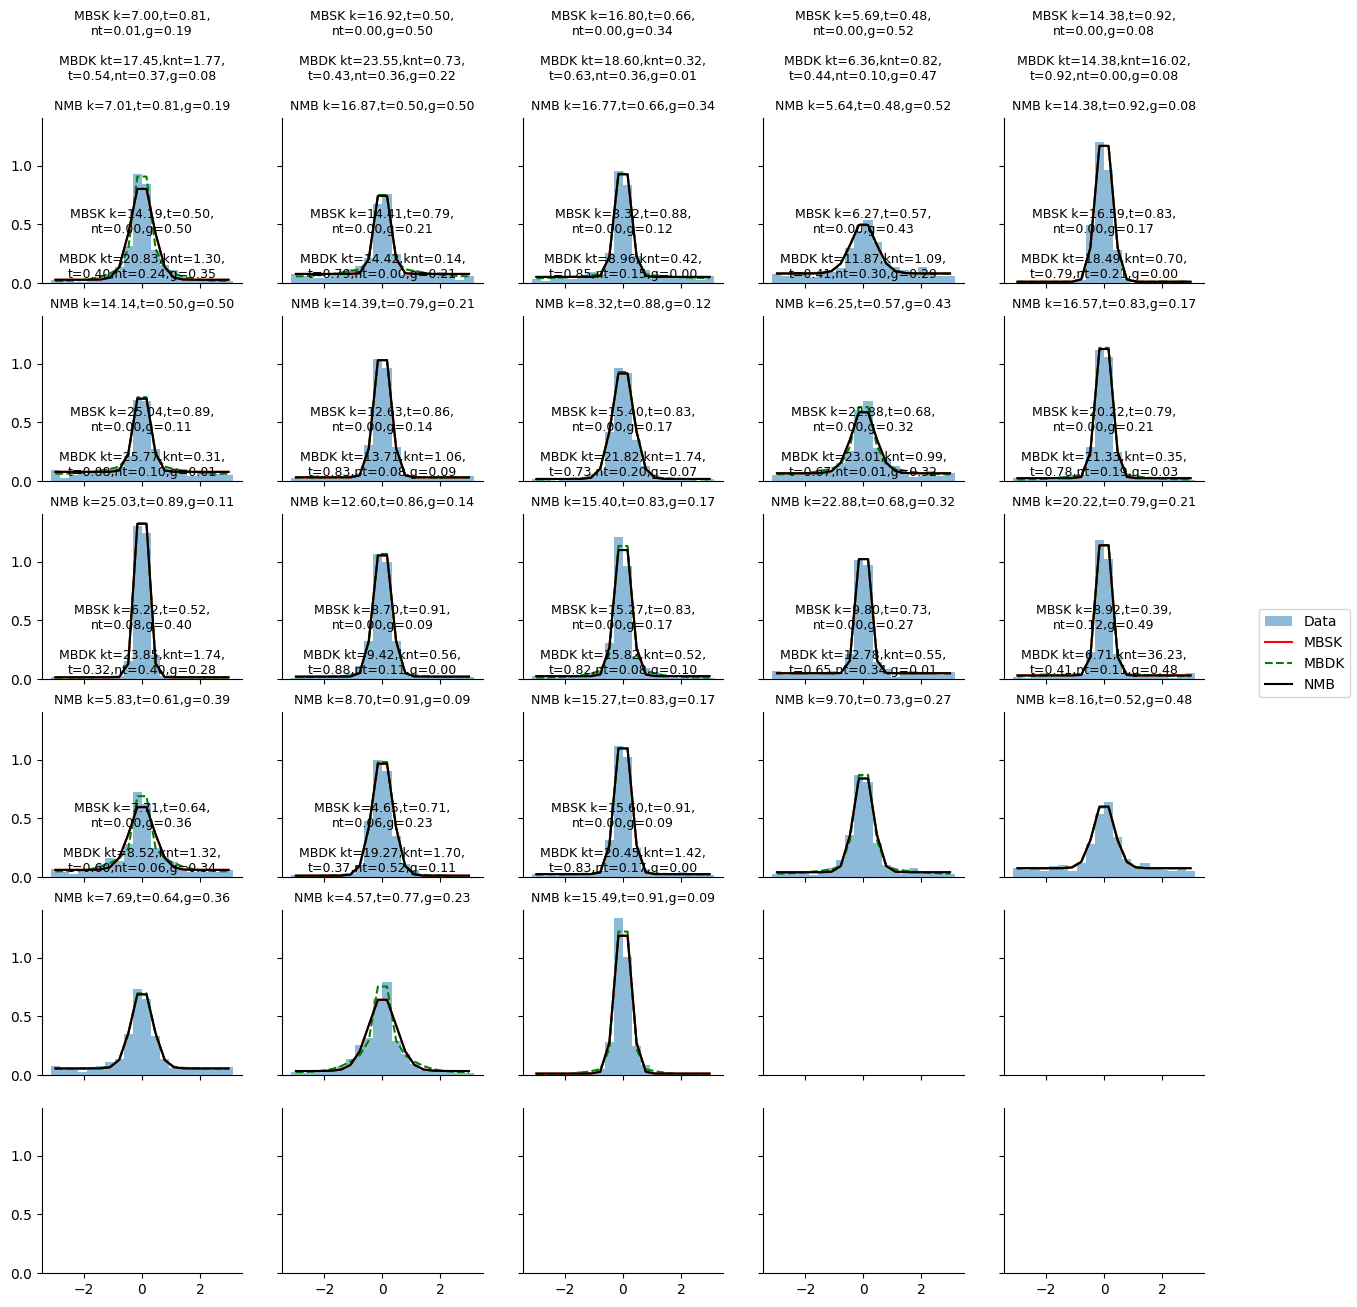

In [4]:
fig,ax = pyplot.subplots(6,5,figsize=(15,15),sharex=True,sharey=True)
participantIndex = 0

for participant in numpy.unique(allParticipantData['Subject']):
    participantData = allParticipantData[allParticipantData['Subject']==participant]
    
    hist,binEdges = numpy.histogram(participantData['Response error']*numpy.pi/180,
                                    bins=20,range=(-numpy.pi, numpy.pi),density=True)
    binCenters = (binEdges[:-1]+binEdges[1:])/2

    axX = participantIndex%5
    axY = numpy.int64(numpy.floor(participantIndex/5))

    labels = ["","","","",""]
    if (participantIndex==0):
        labels = ["Data","MBSK","MBDK",'NMB','Bias']
    ax[axY,axX].hist(participantData['Response error']*numpy.pi/180,bins=20,range=(-numpy.pi, numpy.pi),
                     density=True,alpha=0.5,label=labels[0])
    
    potentialMeans = numpy.linspace(-numpy.pi/9,numpy.pi/9,20)
    
    # MBSK
    MBSKFit = allBaseFits['MBSK'][participantIndex]
    pdf = MBSKFit['targetP']*vonmises.pdf(binCenters,MBSKFit['kappaT'],loc=0)+MBSKFit['guessingP']/(2*numpy.pi)
    pdfNT = [vonmises.pdf(binCenters,MBSKFit['kappaT'],loc=d) for d in potentialMeans]
    pdf += MBSKFit['nonTargetP']*numpy.mean(pdfNT,axis=0)

    ax[axY,axX].plot(binCenters,pdf,'r-',label=labels[1])

    # MBDK
    MBDKFit = allBaseFits['MBDK'][participantIndex]
    pdf = MBDKFit['targetP']*vonmises.pdf(binCenters,MBDKFit['kappaT'],loc=0)+MBDKFit['guessingP']/(2*numpy.pi)
    pdfNT = [vonmises.pdf(binCenters,MBDKFit['kappaNT'],loc=d) for d in potentialMeans]
    pdf += MBDKFit['nonTargetP']*numpy.mean(pdfNT,axis=0)

    ax[axY,axX].plot(binCenters,pdf,'g--',label=labels[2])

    # NMB
    NMBFit = allBaseFits['NMB'][participantIndex]
    pdf = NMBFit['targetP']*vonmises.pdf(binCenters,NMBFit['kappaT'],loc=0)+NMBFit['guessingP']/(2*numpy.pi)

    ax[axY,axX].plot(binCenters,pdf,'k-',label=labels[3])

    # Bias
    # BiasFit = allBaseFits['Bias'][participantIndex]
    # pdf = (1-BiasFit['guessingP'])*vonmises.pdf(binCenters,)

    # ax[axY,axX].plot(binCenters,pdf,'m--',label=labels[4])

    # ax[axY,axX].plot(binCenters,
    #                  vonmises.pdf(binCenters,vonmisesFit[0],loc=vonmisesFit[1]),
    #                  'g-',label=labels[2])

    participantIndex += 1

    title = f'MBSK k={MBSKFit["kappaT"]:.2f},t={MBSKFit["targetP"]:.2f},\nnt={MBSKFit["nonTargetP"]:.2f},g={MBSKFit["guessingP"]:.2f}'
    title += f'\n\nMBDK kt={MBDKFit["kappaT"]:.2f},knt={MBDKFit["kappaNT"]:.2f},\nt={MBDKFit["targetP"]:.2f},nt={MBDKFit["nonTargetP"]:.2f},g={MBDKFit["guessingP"]:.2f}'
    title += f'\n\nNMB k={NMBFit["kappaT"]:.2f},t={NMBFit["targetP"]:.2f},g={NMBFit["guessingP"]:.2f}'

    ax[axY,axX].set_title(title,fontsize=9)

seaborn.despine()
fig.legend(loc="center right")

In [5]:
allParticipantData

,Block,Response time,Trial type,Continuous target,Response error,Accuracy,Response error (absolute),Subject,Mean target,Flipped error,Target section,Response time (correct)
0,1,1.500059,Chunkable,0,29.763980,0,29.763980,302,0,-29.763980,0,NaN
1,1,1.579613,Chunkable,27,157.095231,0,157.095231,302,0,-157.095231,0,NaN
2,1,1.499683,Chunkable,553,-8.376620,1,8.376620,302,540,8.376620,3,1.499683
3,1,1.219558,Chunkable,877,70.916406,0,70.916406,302,900,70.916406,5,NaN
4,1,1.489377,Chunkable,708,14.537678,1,14.537678,302,720,14.537678,4,1.489377
...,...,...,...,...,...,...,...,...,...,...,...,...
20414,20,0.999531,Chunkable,702,-1.832728,1,1.832728,362,720,-1.832728,4,0.999531
20415,20,2.309558,Chunkable,388,-67.210601,0,67.210601,362,360,67.210601,2,NaN
20416,20,1.039724,Chunkable,557,-2.723829,1,2.723829,362,540,2.723829,3,1.039724
20417,20,0.789524,Chunkable,923,-15.434845,1,15.434845,362,900,15.434845,5,0.789524


## <span style='color:Red'>Fit all trials together</span>

In [8]:
if not os.path.exists(exportsPathTemp+'allFits.pkl'):
    allFits,allLL = jlib.analysis.models.fitAllBiasModelsCV(allParticipantData,'all',metricToCalculate,nFolds=10,nJobs=5)
    with open(exportsPathTemp+'allFits.pkl','wb') as fp:
        pickle.dump(allFits,fp)
    with open(exportsPathTemp+'allLL.pkl','wb') as fp:
        pickle.dump(allLL,fp)
else:
    with open(exportsPathTemp+'allFits.pkl','rb') as fp:
        allFits = pickle.load(fp)
    with open(exportsPathTemp+'allLL.pkl','rb') as fp:
        allLL = pickle.load(fp)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:  2.9min
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:  5.4min
[Parallel(n_jobs=5)]: Done  17 out of  23 | elapsed:  8.4min remaining:  3.0min
[Parallel(n_jobs=5)]: Done  20 out of  23 | elapsed: 10.1min remaining:  1.5min
[Parallel(n_jobs=5)]: Done  23 out of  23 | elapsed: 10.9min finished


In [9]:
finalLLTrain = {'MBSK_all':[],'MBDK_all':[],'Bias_all':[],'NMB_all':[]}
finalLLTest = {'MBSK_all':[],'MBDK_all':[],'Bias_all':[],'NMB_all':[]}

for participant in numpy.unique(allParticipantData['Subject']):
    a = numpy.array(allLL['MBSK'][participant])
    b = numpy.array(allLL['MBDK'][participant])
    c = numpy.array(allLL['NMB'][participant])
    d = numpy.array(allLL['Bias'][participant])

    finalLLTrain['MBSK_all'].append(numpy.sum(a,axis=0)[0])
    finalLLTrain['MBDK_all'].append(numpy.sum(b,axis=0)[0])
    finalLLTrain['NMB_all'].append(numpy.sum(c,axis=0)[0])
    finalLLTrain['Bias_all'].append(numpy.sum(d,axis=0)[0])

    finalLLTest['MBSK_all'].append(numpy.sum(a,axis=0)[1])
    finalLLTest['MBDK_all'].append(numpy.sum(b,axis=0)[1])
    finalLLTest['NMB_all'].append(numpy.sum(c,axis=0)[1])
    finalLLTest['Bias_all'].append(numpy.sum(d,axis=0)[1])

numpy.sum(finalLLTrain['MBSK_all']),numpy.sum(finalLLTrain['MBDK_all']),numpy.sum(finalLLTrain['NMB_all']),numpy.sum(finalLLTrain['Bias_all'])

(-218.37452192853587,
 -216.5222082208675,
 -218.4092735028352,
 -208.35162022793065)

In [10]:
numpy.sum(finalLLTest['MBSK_all']),numpy.sum(finalLLTest['MBDK_all']),numpy.sum(finalLLTest['NMB_all']),numpy.sum(finalLLTest['Bias_all'])

(-219.06639614630274,
 -217.53243090826624,
 -219.06094961599675,
 -209.36347878826913)

In [11]:
allFits['Bias']

{302: [{'kappa': 6.4007791605555,
   'bias': -0.04135129670471275,
   'guessingP': 0.1795755314801652},
  {'kappa': 6.849824133739119,
   'bias': 0.011148787236782656,
   'guessingP': 0.18749270658919875},
  {'kappa': 7.1521960555896245,
   'bias': -0.028793251717388228,
   'guessingP': 0.18968388680276185},
  {'kappa': 6.268291474116128,
   'bias': -0.040069826331977115,
   'guessingP': 0.18117770913778444},
  {'kappa': 7.515830549524718,
   'bias': 0.024042252677858197,
   'guessingP': 0.1993107752412771},
  {'kappa': 7.6604942938176235,
   'bias': -0.058162490275276424,
   'guessingP': 0.19358302821127576},
  {'kappa': 6.449379886589193,
   'bias': -0.06583999237124383,
   'guessingP': 0.16632170825481032},
  {'kappa': 7.1938102799373125,
   'bias': -0.03598026530604166,
   'guessingP': 0.18440397135944975},
  {'kappa': 7.237567518075386,
   'bias': -0.024733303283323845,
   'guessingP': 0.19132701866490764},
  {'kappa': 6.948284801660123,
   'bias': -0.024585727517209107,
   'guess

## <span style='color:Red'>Fit chunking vs non-chunking trials</span>

In [12]:
chunkingData = allParticipantData.copy()
chunkingData.drop(chunkingData[chunkingData['Trial type']=='Non-chunkable'].index,axis=0,inplace=True)
nonChunkingData = allParticipantData.copy()
nonChunkingData.drop(nonChunkingData[nonChunkingData['Trial type']=='Chunkable'].index,axis=0,inplace=True)

if not os.path.exists(exportsPathTemp+'allFitsChunking.pkl'):
    allFitsChunking,allLLChunking = jlib.analysis.models.fitAllBiasModelsCV(chunkingData,'all',metricToCalculate,nFolds=10,nJobs=5)
    with open(exportsPathTemp+'allFitsChunking.pkl','wb') as fp:
        pickle.dump(allFitsChunking,fp)
    with open(exportsPathTemp+'allLLChunking.pkl','wb') as fp:
        pickle.dump(allLLChunking,fp)

    allFitsNonChunking,allLLNonChunking = jlib.analysis.models.fitAllBiasModelsCV(nonChunkingData,'all',metricToCalculate,nFolds=10,nJobs=5)
    with open(exportsPathTemp+'allFitsNonChunking.pkl','wb') as fp:
        pickle.dump(allFitsNonChunking,fp)
    with open(exportsPathTemp+'allLLNonChunking.pkl','wb') as fp:
        pickle.dump(allLLNonChunking,fp)
else:
    with open(exportsPathTemp+'allFitsChunking.pkl','rb') as fp:
        allFitsChunking = pickle.load(fp)
    with open(exportsPathTemp+'allLLChunking.pkl','rb') as fp:
        allLLChunking = pickle.load(fp)
    with open(exportsPathTemp+'allFitsNonChunking.pkl','rb') as fp:
        allFitsNonChunking = pickle.load(fp)
    with open(exportsPathTemp+'allLLNonChunking.pkl','rb') as fp:
        allLLNonChunking = pickle.load(fp)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:  1.5min
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:  3.2min
[Parallel(n_jobs=5)]: Done  17 out of  23 | elapsed:  5.4min remaining:  1.9min
[Parallel(n_jobs=5)]: Done  20 out of  23 | elapsed:  6.4min remaining:   57.4s
[Parallel(n_jobs=5)]: Done  23 out of  23 | elapsed:  7.5min finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:   52.0s
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:  1.9min
[Parallel(n_jobs=5)]: Done  17 out of  23 | elapsed:  4.0min remaining:  1.4min
[Parallel(n_jobs=5)]: Done  20 out of  23 | elapsed:  4.5min remaining:   40.8s
[Parallel(n_jobs=5)]: Done  23 out of  23 | elapsed:  5.2min finished


In [13]:
propsToAdd = ['MBSK_C_all','MBDK_C_all','Bias_C_all','NMB_C_all',
              'MBSK_NC_all','MBDK_NC_all','Bias_NC_all','NMB_NC_all']
for prop in propsToAdd:
    finalLLTrain[prop] = []
    finalLLTest[prop] = []

for participant in numpy.unique(allParticipantData['Subject']):
    a = numpy.array(allLLChunking['MBSK'][participant])
    b = numpy.array(allLLChunking['MBDK'][participant])
    c = numpy.array(allLLChunking['NMB'][participant])
    d = numpy.array(allLLChunking['Bias'][participant])

    finalLLTrain['MBSK_C_all'].append(numpy.sum(a,axis=0)[0])
    finalLLTrain['MBDK_C_all'].append(numpy.sum(b,axis=0)[0])
    finalLLTrain['NMB_C_all'].append(numpy.sum(c,axis=0)[0])
    finalLLTrain['Bias_C_all'].append(numpy.sum(d,axis=0)[0])

    finalLLTest['MBSK_C_all'].append(numpy.sum(a,axis=0)[1])
    finalLLTest['MBDK_C_all'].append(numpy.sum(b,axis=0)[1])
    finalLLTest['NMB_C_all'].append(numpy.sum(c,axis=0)[1])
    finalLLTest['Bias_C_all'].append(numpy.sum(d,axis=0)[1])

    a = numpy.array(allLLNonChunking['MBSK'][participant])
    b = numpy.array(allLLNonChunking['MBDK'][participant])
    c = numpy.array(allLLNonChunking['NMB'][participant])
    d = numpy.array(allLLNonChunking['Bias'][participant])

    finalLLTrain['MBSK_NC_all'].append(numpy.sum(a,axis=0)[0])
    finalLLTrain['MBDK_NC_all'].append(numpy.sum(b,axis=0)[0])
    finalLLTrain['NMB_NC_all'].append(numpy.sum(c,axis=0)[0])
    finalLLTrain['Bias_NC_all'].append(numpy.sum(d,axis=0)[0])

    finalLLTest['MBSK_NC_all'].append(numpy.sum(a,axis=0)[1])
    finalLLTest['MBDK_NC_all'].append(numpy.sum(b,axis=0)[1])
    finalLLTest['NMB_NC_all'].append(numpy.sum(c,axis=0)[1])
    finalLLTest['Bias_NC_all'].append(numpy.sum(d,axis=0)[1])

[numpy.sum(finalLLTrain['MBSK_C_all']),numpy.sum(finalLLTrain['MBDK_C_all']),
 numpy.sum(finalLLTrain['NMB_C_all']),numpy.sum(finalLLTrain['Bias_C_all'])]

[-198.90155842625387,
 -197.161054699035,
 -198.92098644305761,
 -186.44085443788282]

In [14]:
[numpy.sum(finalLLTest['MBSK_C_all']),numpy.sum(finalLLTest['MBDK_C_all']),
 numpy.sum(finalLLTest['NMB_C_all']),numpy.sum(finalLLTest['Bias_C_all'])]

[-199.85692414164095,
 -198.29853014377153,
 -199.8355452045676,
 -187.71538104465589]

In [15]:
[numpy.sum(finalLLTrain['MBSK_NC_all']),numpy.sum(finalLLTrain['MBDK_NC_all']),
 numpy.sum(finalLLTrain['NMB_NC_all']),numpy.sum(finalLLTrain['Bias_NC_all'])]

[-279.5547580460261,
 -276.2587463650089,
 -279.9577016317972,
 -275.6901783409593]

In [16]:
[numpy.sum(finalLLTest['MBSK_NC_all']),numpy.sum(finalLLTest['MBDK_NC_all']),
 numpy.sum(finalLLTest['NMB_NC_all']),numpy.sum(finalLLTest['Bias_NC_all'])]

[-283.6973619007981,
 -283.0066240914198,
 -283.64053953230064,
 -281.21631306479486]

In [17]:
allFitsChunking['Bias']

{302: [{'kappa': 6.02135501004753,
   'bias': -0.006724083653726513,
   'guessingP': 0.15764432666628797},
  {'kappa': 6.188152833891306,
   'bias': 0.05337483212393628,
   'guessingP': 0.1374567452371826},
  {'kappa': 6.16209841065792,
   'bias': 0.02707880340678276,
   'guessingP': 0.15399763079093737},
  {'kappa': 6.701210939437385,
   'bias': 0.05573818883940759,
   'guessingP': 0.15840375765801315},
  {'kappa': 6.245279598056821,
   'bias': 0.050734678358641566,
   'guessingP': 0.14026453410418716},
  {'kappa': 6.387528879067057,
   'bias': 0.06639942987128389,
   'guessingP': 0.14324562861619014},
  {'kappa': 6.474090026914766,
   'bias': 0.03892087540800848,
   'guessingP': 0.15457900996024973},
  {'kappa': 6.470056715130072,
   'bias': 0.029745364350000757,
   'guessingP': 0.1491360004267786},
  {'kappa': 6.623133315149587,
   'bias': -0.026894544824234777,
   'guessingP': 0.16070617370122825},
  {'kappa': 6.87875050563476,
   'bias': -0.0013186970026749095,
   'guessingP': 0.1

## <span style='color:Red'>Fit chunking vs non-chunking good trials (makes no sense to do)</span>

In [18]:
# chunkingGData = chunkingData.copy()
# chunkingGData.drop(chunkingGData[chunkingGData['Response error (absolute)']<40].index,axis=0,inplace=True)
# nonChunkingGData = nonChunkingData.copy()
# nonChunkingGData.drop(nonChunkingGData[nonChunkingGData['Response error (absolute)']<40].index,axis=0,inplace=True)

# allFitsChunkingG,allLLChunkingG = jlib.analysis.models.fitAllBiasModelsCV(chunkingGData,'all','LL',nFolds=10,nJobs=5)
# allFitsNonChunkingG,allLLNonChunkingG = jlib.analysis.models.fitAllBiasModelsCV(nonChunkingGData,'all','LL',nFolds=10,nJobs=5)

In [19]:
finalLLTrain['Subject'] = numpy.unique(allParticipantData['Subject'])
finalLLTest['Subject'] = numpy.unique(allParticipantData['Subject'])

finalLLTrainDF = pandas.DataFrame.from_dict(finalLLTrain)
finalLLTestDF = pandas.DataFrame.from_dict(finalLLTest)

finalLLTrainDF.to_csv(exportsPath+"modelsTrainLL.csv")
finalLLTestDF.to_csv(exportsPath+"modelsTestLL.csv")

In [20]:
finalLLTestDF

,MBSK_all,MBDK_all,Bias_all,NMB_all,MBSK_C_all,MBDK_C_all,Bias_C_all,NMB_C_all,MBSK_NC_all,MBDK_NC_all,Bias_NC_all,NMB_NC_all,Subject
0,-9.954924,-9.680582,-9.956973,-9.949868,-9.513140,-9.248333,-9.526843,-9.511735,-11.637008,-11.802588,-11.604963,-11.587237,302
1,-13.603872,-13.489288,-13.422886,-13.603454,-13.164763,-13.093497,-12.954002,-13.165059,-15.188975,-15.169024,-15.173602,-15.165149,303
2,-10.573750,-10.539437,-10.132728,-10.573511,-10.371982,-10.380922,-9.804492,-10.372019,-11.392393,-10.863415,-11.384777,-11.387938,305
3,-15.705678,-15.727017,-15.644457,-15.705918,-15.634981,-15.640528,-15.529483,-15.634686,-16.078672,-16.142746,-16.091807,-16.049672,306
4,-4.502247,-4.502247,-3.012235,-4.502245,-3.447288,-3.447287,-1.876294,-3.447285,-8.178938,-8.220292,-6.993312,-8.178888,307
5,-13.962470,-13.868498,-13.931402,-13.961185,-13.847458,-13.774444,-13.816654,-13.847021,-14.796655,-14.513999,-14.791291,-14.730449,308
6,-8.004441,-8.004474,-7.493383,-8.004295,-7.231972,-7.232330,-6.441072,-7.232277,-10.834683,-10.824353,-10.868389,-10.786885,309
7,-7.848260,-7.838486,-6.689117,-7.848227,-5.881045,-5.874829,-4.404986,-5.880815,-13.736940,-13.744799,-13.611500,-13.732898,310
8,-14.372278,-14.424116,-14.382674,-14.371491,-14.122909,-14.151651,-14.133263,-14.122728,-15.390724,-15.247582,-15.397817,-15.330389,313
9,-6.335533,-6.227711,-5.502346,-6.335756,-4.969493,-4.770101,-3.988597,-4.969501,-10.834020,-10.881517,-10.681846,-10.833894,314


## <span style='color:Red'>ANOVA on testing LLs</span>

### <span style='color:Red'>Fits on all data</span>

In [21]:
allDataModelDF = pandas.DataFrame({'Subject':numpy.unique(finalLLTestDF['Subject']),
                                   'MBSKTestLL':finalLLTestDF['MBSK_all'],
                                   'MBDKTestLL':finalLLTestDF['MBDK_all'],
                                   'NMBTestLL':finalLLTestDF['NMB_all'],
                                   'BiasTestLL':finalLLTestDF['Bias_all']})

# allDataANOVA = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
#                                            data=allDataModelDF,
#                                            rmLabels=['Model'],
#                                            rmLists=[['MBSK','MBDK','NMB','Bias']],
#                                            rmMeasureName='TestLL',
#                                            rmTerms='~Model',
#                                            sphericityTest=True,
#                                            effectSize=[desiredEffectSize])

# allDataANOVA['within'].columns = allDataANOVA['within'].columns.str.rstrip('[none]')

allDataANOVA = jlib.analysis.anova.anovaRMNP(rPath='C:/Program Files/R/R-4.4.1/',
                                             data=allDataModelDF,
                                             measurements=['MBSKTestLL','MBDKTestLL','NMBTestLL','BiasTestLL'])

mapValueHandler.setKeyValue("anovaModelFitsAll",
                            jlib.data.constants.extractFriedmanResults(allDataANOVA['within'],
                                                                       allDataModelDF.shape[0],4))

allDataANOVA

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: package 'jmv' was built under R version 4.4.3 



{'within':          stat   df         p
 "1"  19.53913  3.0  0.000211}

In [22]:
allDataTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                      variables=[allDataModelDF['MBDKTestLL']-allDataModelDF['MBSKTestLL'],
                                                                 allDataModelDF['NMBTestLL']-allDataModelDF['MBSKTestLL'],
                                                                 allDataModelDF['BiasTestLL']-allDataModelDF['MBSKTestLL'],
                                                                 allDataModelDF['NMBTestLL']-allDataModelDF['MBDKTestLL'],
                                                                 allDataModelDF['BiasTestLL']-allDataModelDF['MBDKTestLL'],
                                                                 allDataModelDF['BiasTestLL']-allDataModelDF['NMBTestLL']],
                                                       testValue=0,isStudent=False,isWilcoxon=True,hypothesis='dt',
                                                       effectSize=True,descriptives=True)

allDataTtestOS['ttest'].columns = allDataTtestOS['ttest'].columns.str.rstrip('[wilc]')

mapValueHandler.setKeyValue("ttestOSAllTrialDiffMBDK-MBSK",
                            jlib.data.constants.extractWilcoxonResults(allDataTtestOS['ttest'],0,6))

mapValueHandler.setKeyValue("ttestOSAllTrialDiffNMB-MBSK",
                            jlib.data.constants.extractWilcoxonResults(allDataTtestOS['ttest'],1,6))

mapValueHandler.setKeyValue("ttestOSAllTrialDiffBias-MBSK",
                            jlib.data.constants.extractWilcoxonResults(allDataTtestOS['ttest'],2,6))

mapValueHandler.setKeyValue("ttestOSAllTrialDiffNMB-MBDK",
                            jlib.data.constants.extractWilcoxonResults(allDataTtestOS['ttest'],3,6))

mapValueHandler.setKeyValue("ttestOSAllTrialDiffBias-MBDK",
                            jlib.data.constants.extractWilcoxonResults(allDataTtestOS['ttest'],4,6))

mapValueHandler.setKeyValue("ttestOSAllTrialDiffBias-NMB",
                            jlib.data.constants.extractWilcoxonResults(allDataTtestOS['ttest'],5,6))

allDataTtestOS

{'ttest':          var        name   stat         p                     esType        es
 "set0"  set0  Wilcoxon W  215.0  0.017873  Rank biserial correlation  0.557971
 "set1"  set1  Wilcoxon W  165.0  0.427418  Rank biserial correlation  0.195652
 "set2"  set2  Wilcoxon W  266.0  0.000010  Rank biserial correlation  0.927536
 "set3"  set3  Wilcoxon W   62.0  0.019557  Rank biserial correlation -0.550725
 "set4"  set4  Wilcoxon W  237.0  0.001660  Rank biserial correlation  0.717391
 "set5"  set5  Wilcoxon W  267.0  0.000008  Rank biserial correlation  0.934783,
 'normality':         name         w             p
 "set0"  set0  0.833524  1.387543e-03
 "set1"  set1  0.588799  6.815176e-07
 "set2"  set2  0.855372  3.409659e-03
 "set3"  set3  0.839565  1.770156e-03
 "set4"  set4  0.901887  2.765321e-02
 "set5"  set5  0.856156  3.524877e-03,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   23  0.066694  0.011190  0.103464  0.021574
 "set1"  set1   

### <span style='color:Red'>Fits on chunking data</span>

In [23]:
chunkingDataModelDF = pandas.DataFrame({'Subject':numpy.unique(finalLLTestDF['Subject']),
                                        'MBSKTestLL':finalLLTestDF['MBSK_C_all'],
                                        'MBDKTestLL':finalLLTestDF['MBDK_C_all'],
                                        'NMBTestLL':finalLLTestDF['NMB_C_all'],
                                        'BiasTestLL':finalLLTestDF['Bias_C_all']})

# chunkingDataANOVA = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
#                                      data=chunkingDataModelDF,
#                                      rmLabels=['Model'],
#                                      rmLists=[['MBSK','MBDK','NMB','Bias']],
#                                      rmMeasureName='TestLL',
#                                      rmTerms='~Model',
#                                      sphericityTest=True,
#                                      effectSize=[desiredEffectSize])

# chunkingDataANOVA['within'].columns = chunkingDataANOVA['within'].columns.str.rstrip('[none]')

chunkingDataANOVA = jlib.analysis.anova.anovaRMNP(rPath='C:/Program Files/R/R-4.4.1/',
                                                  data=chunkingDataModelDF,
                                                  measurements=['MBSKTestLL','MBDKTestLL','NMBTestLL','BiasTestLL'])

mapValueHandler.setKeyValue("anovaModelFitsChunking",
                            jlib.data.constants.extractFriedmanResults(chunkingDataANOVA['within'],
                                                                       allDataModelDF.shape[0],4))

chunkingDataANOVA

{'within':           stat   df         p
 "1"  20.582609  3.0  0.000129}

In [24]:
variablesToTest = [chunkingDataModelDF['MBDKTestLL']-chunkingDataModelDF['MBSKTestLL'],
                   chunkingDataModelDF['NMBTestLL']-chunkingDataModelDF['MBSKTestLL'],
                   chunkingDataModelDF['BiasTestLL']-chunkingDataModelDF['MBSKTestLL'],
                   chunkingDataModelDF['NMBTestLL']-chunkingDataModelDF['MBDKTestLL'],
                   chunkingDataModelDF['BiasTestLL']-chunkingDataModelDF['MBDKTestLL'],
                   chunkingDataModelDF['BiasTestLL']-chunkingDataModelDF['NMBTestLL']]

chunkingDataTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           variables=variablesToTest,
                                                           testValue=0,isStudent=False,isWilcoxon=True,hypothesis='dt',
                                                           effectSize=True,descriptives=True)

chunkingDataTtestOS['ttest'].columns = chunkingDataTtestOS['ttest'].columns.str.rstrip('[wilc]')

mapValueHandler.setKeyValue("ttestOSCTrialDiffMBDK-MBSK",
                            jlib.data.constants.extractWilcoxonResults(chunkingDataTtestOS['ttest'],0,6))

mapValueHandler.setKeyValue("ttestOSCTrialDiffNMB-MBSK",
                            jlib.data.constants.extractWilcoxonResults(chunkingDataTtestOS['ttest'],1,6))

mapValueHandler.setKeyValue("ttestOSCTrialDiffBias-MBSK",
                            jlib.data.constants.extractWilcoxonResults(chunkingDataTtestOS['ttest'],2,6))

mapValueHandler.setKeyValue("ttestOSCTrialDiffNMB-MBDK",
                            jlib.data.constants.extractWilcoxonResults(chunkingDataTtestOS['ttest'],3,6))

mapValueHandler.setKeyValue("ttestOSCTrialDiffBias-MBDK",
                            jlib.data.constants.extractWilcoxonResults(chunkingDataTtestOS['ttest'],4,6))

mapValueHandler.setKeyValue("ttestOSCTrialDiffBias-NMB",
                            jlib.data.constants.extractWilcoxonResults(chunkingDataTtestOS['ttest'],5,6))

chunkingDataTtestOS

{'ttest':          var        name   stat         p                     esType        es
 "set0"  set0  Wilcoxon W  194.0  0.091753  Rank biserial correlation  0.405797
 "set1"  set1  Wilcoxon W  199.0  0.065036  Rank biserial correlation  0.442029
 "set2"  set2  Wilcoxon W  267.0  0.000008  Rank biserial correlation  0.934783
 "set3"  set3  Wilcoxon W   83.0  0.097988  Rank biserial correlation -0.398551
 "set4"  set4  Wilcoxon W  237.0  0.001660  Rank biserial correlation  0.717391
 "set5"  set5  Wilcoxon W  264.0  0.000017  Rank biserial correlation  0.913043,
 'normality':         name         w             p
 "set0"  set0  0.782013  2.002118e-04
 "set1"  set1  0.448962  2.888445e-08
 "set2"  set2  0.855626  3.446614e-03
 "set3"  set3  0.779939  1.860952e-04
 "set4"  set4  0.897548  2.251050e-02
 "set5"  set5  0.855931  3.491394e-03,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   23  0.067756  0.000001  0.106437  0.022194
 "set1"  set1   

### <span style='color:Red'>Fits on non-chunking data</span>

In [25]:
nonChunkingDataModelDF = pandas.DataFrame({'Subject':numpy.unique(finalLLTestDF['Subject']),
                                           'MBSKTestLL':finalLLTestDF['MBSK_NC_all'],
                                           'MBDKTestLL':finalLLTestDF['MBDK_NC_all'],
                                           'NMBTestLL':finalLLTestDF['NMB_NC_all'],
                                           'BiasTestLL':finalLLTestDF['Bias_NC_all']})

# nonChunkingDataANOVA = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
#                                                    data=nonChunkingDataModelDF,
#                                                    rmLabels=['Model'],
#                                                    rmLists=[['MBSK','MBDK','NMB','Bias']],
#                                                    rmMeasureName='TestLL',
#                                                    rmTerms='~Model',
#                                                    sphericityTest=True,
#                                                    effectSize=[desiredEffectSize])

# nonChunkingDataANOVA['within'].columns = nonChunkingDataANOVA['within'].columns.str.rstrip('[none]')

nonChunkingDataANOVA = jlib.analysis.anova.anovaRMNP(rPath='C:/Program Files/R/R-4.4.1/',
                                                     data=nonChunkingDataModelDF,
                                                     measurements=['MBSKTestLL','MBDKTestLL','NMBTestLL','BiasTestLL'])

mapValueHandler.setKeyValue("anovaModelFitsNonChunking",
                            jlib.data.constants.extractFriedmanResults(nonChunkingDataANOVA['within'],
                                                                       allDataModelDF.shape[0],4))

nonChunkingDataANOVA

{'within':          stat   df         p
 "1"  6.078261  3.0  0.107864}

In [26]:
mapValueHandler.saveData()

All data saved correctly to exports/exp3Values.csv
